In [7]:
import os
from dotenv import load_dotenv
from garminconnect import Garmin
import datetime
import json
import time

# Wczytaj zmienne z pliku .env
load_dotenv()

# Pobierz dane ze zmiennych środowiskowych
EMAIL = os.getenv("GARMIN_EMAIL")
PASSWORD = os.getenv("GARMIN_PASSWORD")
START_DATE = datetime.date(2025, 12, 1)
END_DATE = datetime.date(2026, 3, 16)

# Ścieżka do folderu
SAVE_PATH = os.path.join("data", "garmin-connect-json")

def setup_folders():
    """Tworzy foldery, jeśli nie istnieją."""
    if not os.path.exists(SAVE_PATH):
        os.makedirs(SAVE_PATH)
        print(f"Utworzono folder: {SAVE_PATH}")

def download_sleep_data():
    setup_folders()

    try:
        print("Logowanie do Garmin Connect...")
        client = Garmin(EMAIL, PASSWORD)
        client.login()
        print("Zalogowano!\n")

        current_date = START_DATE
        while current_date <= END_DATE:
            date_str = current_date.isoformat()

            try:
                sleep_data = client.get_sleep_data(date_str)

                # --- KLUCZOWA ZMIANA: Walidacja danych ---
                # Sprawdzamy:
                # 1. Czy sleep_data nie jest None
                # 2. Czy zawiera klucz 'dailySleepDTO'
                # 3. Czy wewnątrz 'dailySleepDTO' pole 'sleepTimeSeconds' NIE JEST None

                summary = sleep_data.get("dailySleepDTO") if sleep_data else None

                if summary and summary.get("sleepTimeSeconds") is not None:
                    file_name = f"sleep_{date_str}.json"
                    full_path = os.path.join(SAVE_PATH, file_name)

                    with open(full_path, "w", encoding="utf-8") as f:
                        json.dump(sleep_data, f, indent=4, ensure_ascii=False)

                    print(f"✅ Zapisano: {date_str} ({summary.get('sleepTimeSeconds') // 60} min snu)")
                else:
                    print(f"--- Pominięto: {date_str} (Brak rekordów czasowych / null)")

            except Exception as e:
                print(f"❌ Błąd przy dacie {date_str}: {e}")

            time.sleep(1)
            current_date += datetime.timedelta(days=1)

        print("\nEksport zakończony.")

    except Exception as e:
        print(f"Błąd krytyczny: {e}")

if __name__ == "__main__":
    download_sleep_data()

Logowanie do Garmin Connect...
Zalogowano!

--- Pominięto: 2025-12-01 (Brak rekordów czasowych / null)
--- Pominięto: 2025-12-02 (Brak rekordów czasowych / null)
--- Pominięto: 2025-12-03 (Brak rekordów czasowych / null)
--- Pominięto: 2025-12-04 (Brak rekordów czasowych / null)


KeyboardInterrupt: 

In [8]:
import pandas as pd
import json
import os
import glob

# --- KONFIGURACJA ---
DATA_PATH = os.path.join("data", "garmin-connect-json", "sleep_*.json")

def process_garmin_data():
    all_sleep_records = []

    # Pobranie listy wszystkich plików JSON
    files = glob.glob(DATA_PATH)

    if not files:
        print("Nie znaleziono plików JSON w podanej lokalizacji.")
        return None

    for file_path in files:
        with open(file_path, "r", encoding="utf-8") as f:
            data = json.load(f)

            # Pobieramy główny obiekt z danymi (podsumowanie dnia)
            summary = data.get("dailySleepDTO")

            if summary:
                # Wybieramy interesujące nas kolumny
                record = {
                    "date": summary.get("calendarDate"),
                    "score": summary.get("sleepScore"),
                    "duration_min": summary.get("sleepTimeSeconds", 0) / 60,
                    "deep_sleep_min": summary.get("deepSleepSeconds", 0) / 60,
                    "light_sleep_min": summary.get("lightSleepSeconds", 0) / 60,
                    "rem_sleep_min": summary.get("remSleepSeconds", 0) / 60,
                    "awake_min": summary.get("awakeSleepSeconds", 0) / 60,
                    "restless_moments": summary.get("restlessMomentsCount"),
                    "avg_respiration": summary.get("averageRespiration"),
                    "min_respiration": summary.get("minRespiration"),
                    "max_respiration": summary.get("maxRespiration"),
                    "sleep_start": pd.to_datetime(summary.get("sleepStartTimestampLocal"), unit='ms'),
                    "sleep_end": pd.to_datetime(summary.get("sleepEndTimestampLocal"), unit='ms')
                }
                all_sleep_records.append(record)

    # Tworzenie DataFrame
    df = pd.DataFrame(all_sleep_records)

    # --- DATA CLEARING ---
    # 1. Konwersja daty na obiekt datetime
    df['date'] = pd.to_datetime(df['date'])

    # 2. Sortowanie po dacie
    df = df.sort_values(by='date').reset_index(drop=True)

    # 3. Zaokrąglanie wartości minutowych do 2 miejsc po przecinku
    cols_to_round = ['duration_min', 'deep_sleep_min', 'light_sleep_min', 'rem_sleep_min', 'awake_min']
    df[cols_to_round] = df[cols_to_round].round(2)

    # 4. Obsługa brakujących danych (np. brak score w starszych zegarkach)
    df['score'] = df['score'].fillna(0).astype(int)

    return df

# Wywołanie i wyświetlenie wyników
df_sleep = process_garmin_data()

if df_sleep is not None:
    print("Oczyszczone dane snu (pierwsze 5 rekordów):")
    print(df_sleep.head())

    # Opcjonalnie: zapis do CSV dla Excela
    # df_sleep.to_csv("moj_sen_garmin.csv", index=False)

Oczyszczone dane snu (pierwsze 5 rekordów):
        date  score  duration_min  deep_sleep_min  light_sleep_min  \
0 2026-02-10      0         343.0            85.0            195.0   
1 2026-02-12      0         471.0            76.0            293.0   
2 2026-02-13      0         463.0            91.0            329.0   
3 2026-02-14      0         421.0           117.0            245.0   
4 2026-02-15      0         307.0            38.0            238.0   

   rem_sleep_min  awake_min restless_moments avg_respiration min_respiration  \
0           63.0       21.0             None            None            None   
1          102.0       12.0             None            None            None   
2           43.0       12.0             None            None            None   
3           59.0       19.0             None            None            None   
4           31.0       99.0             None            None            None   

  max_respiration         sleep_start           sleep_

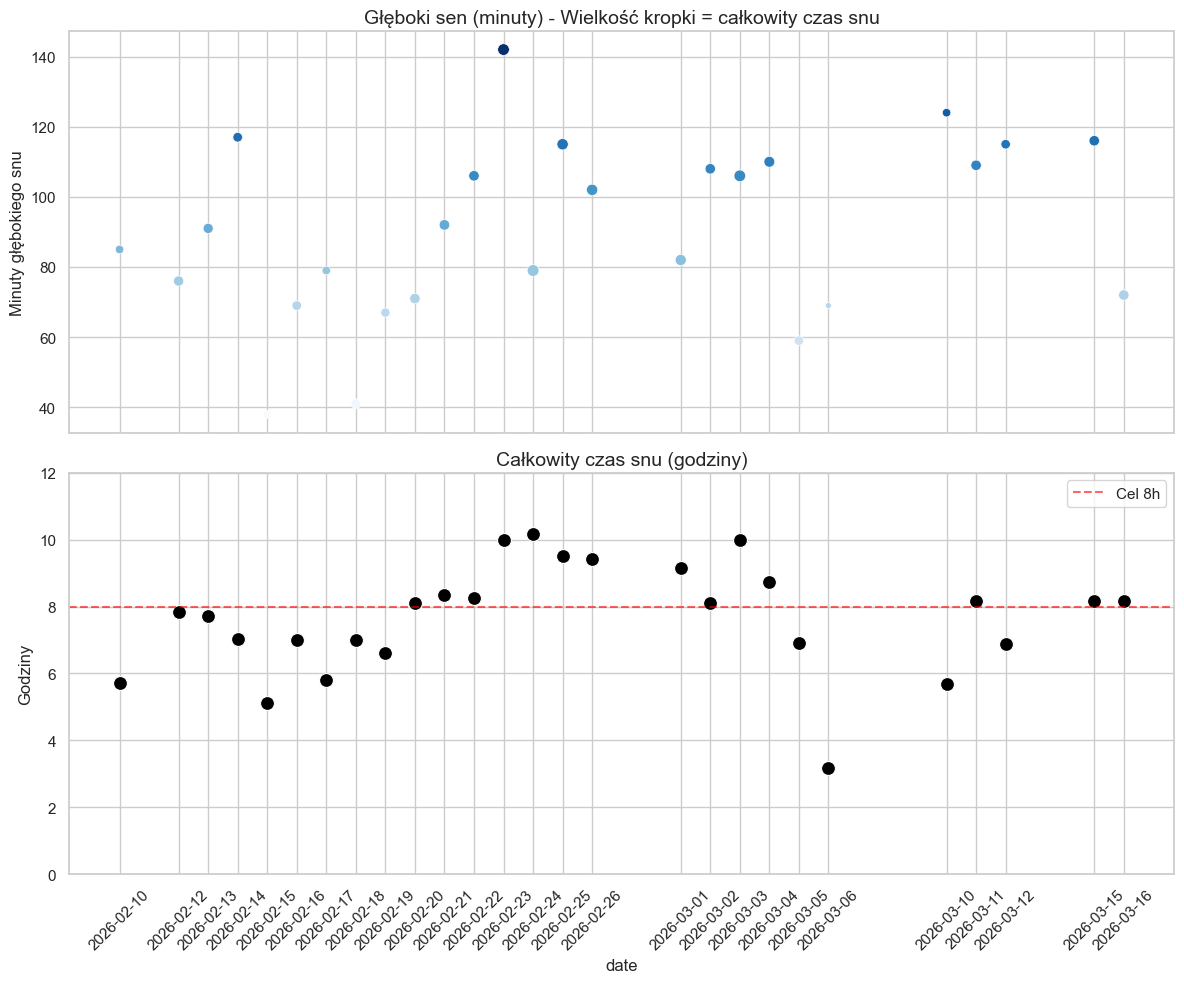

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_sleep_scatter(df):
    # 1. Przygotowanie danych
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    df['duration_hours'] = df['duration_min'] / 60

    # Sortujemy, żeby oś X miała sens
    df = df.sort_values('date')

    # 2. Ustawienia stylu
    sns.set_theme(style="whitegrid")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

    # --- WYKRES 1: Czas głębokiego snu (Scatter) ---
    sns.scatterplot(
        data=df,
        x='date',
        y='deep_sleep_min',
        size='duration_hours', # Wielkość kropki zależy od długości całego snu
        hue='deep_sleep_min',  # Kolor zależy od głębokości
        palette='Blues',
        ax=ax1,
        legend=False
    )
    ax1.set_title('Głęboki sen (minuty) - Wielkość kropki = całkowity czas snu', fontsize=14)
    ax1.set_ylabel('Minuty głębokiego snu')

    # --- WYKRES 2: Całkowity czas snu (Scatter) ---
    sns.scatterplot(
        data=df,
        x='date',
        y='duration_hours',
        color='black',
        s=100, # Stały rozmiar punktów
        ax=ax2
    )

    # Linia celu (8h)
    ax2.axhline(y=8, color='red', linestyle='--', alpha=0.6, label='Cel 8h')

    ax2.set_title('Całkowity czas snu (godziny)', fontsize=14)
    ax2.set_ylabel('Godziny')
    ax2.set_ylim(0, 12)
    ax2.legend()

    # 3. Formatowanie osi X (Daty)
    # Wyświetlamy wszystkie daty, które fizycznie istnieją w danych
    plt.xticks(df['date'], df['date'].dt.strftime('%Y-%m-%d'), rotation=45)

    plt.tight_layout()
    plt.show()

# Wywołanie
plot_sleep_scatter(df_sleep)

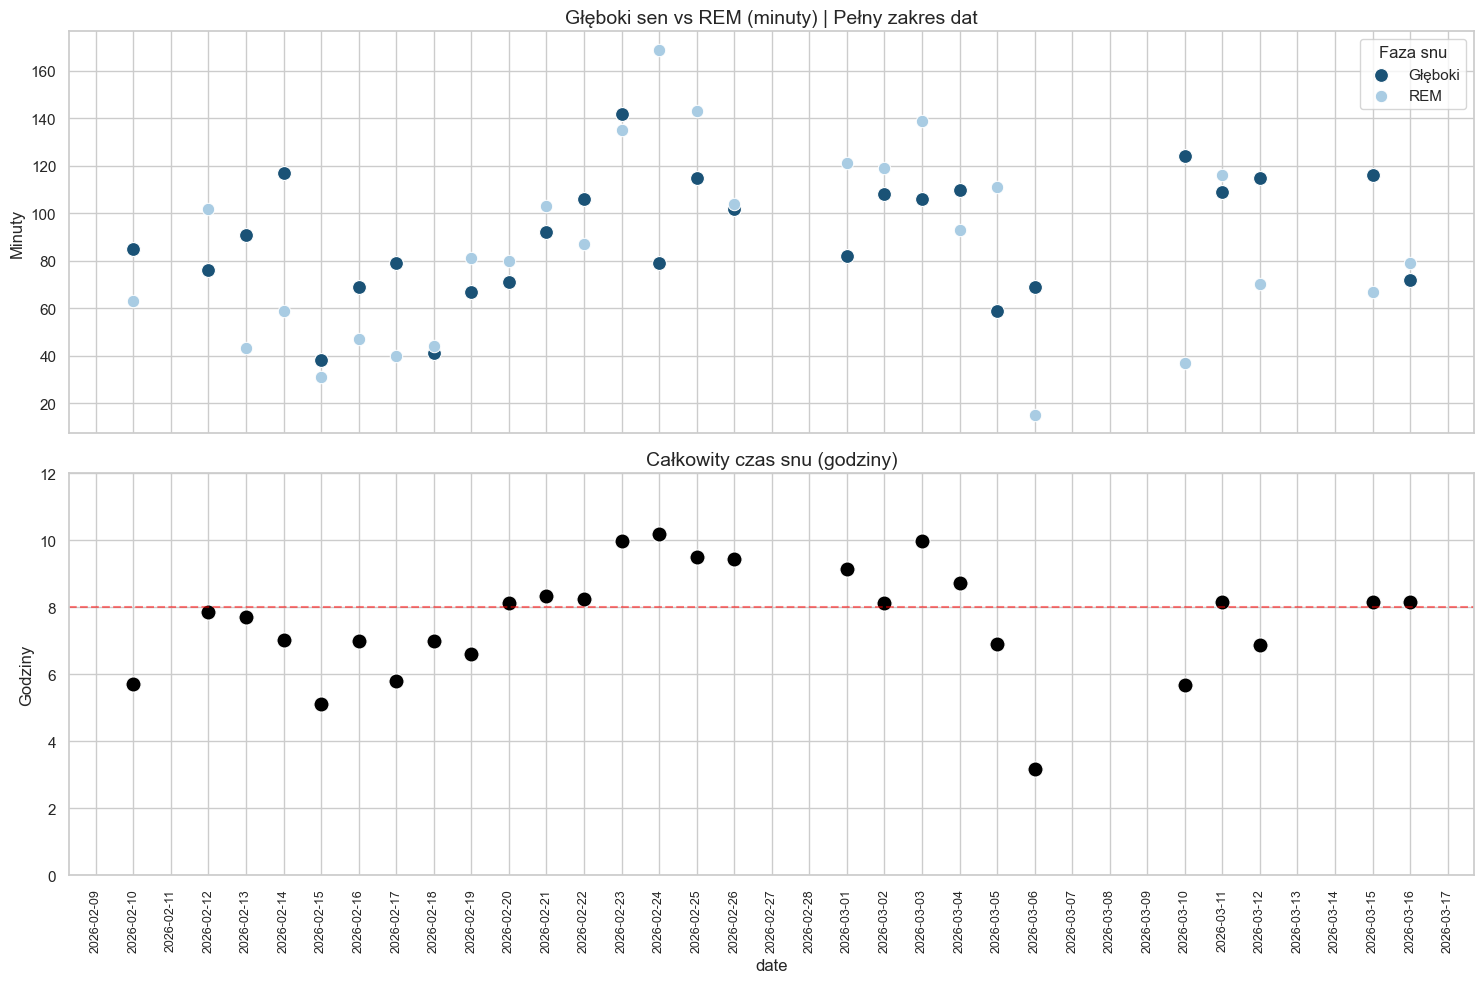

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

def plot_sleep_full_timeline(df):
    # 1. Przygotowanie danych
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])

    # 2. Definiujemy sztywny zakres dat zgodnie z Twoją prośbą
    start_date = "2026-02-10"
    end_date = "2026-03-16"
    full_range = pd.date_range(start=start_date, end=end_date, freq='D')

    # 3. Reindexowanie (tworzy puste wiersze tam, gdzie nie ma danych)
    df_full = df.set_index('date').reindex(full_range).reset_index()
    df_full.rename(columns={'index': 'date'}, inplace=True)

    # Przeliczamy godziny dla nowej ramki
    df_full['duration_hours'] = df_full['duration_min'] / 60

    # 4. Ustawienia stylu
    sns.set_theme(style="whitegrid")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

    # --- WYKRES 1: Fazy snu (Scatter) ---
    # Używamy wielu serii punktów, aby pokazać różne fazy
    sns.scatterplot(data=df_full, x='date', y='deep_sleep_min', color='#1A5276', s=100, label='Głęboki', ax=ax1)
    sns.scatterplot(data=df_full, x='date', y='rem_sleep_min', color='#A9CCE3', s=80, label='REM', ax=ax1)

    ax1.set_title('Głęboki sen vs REM (minuty) | Pełny zakres dat', fontsize=14)
    ax1.set_ylabel('Minuty')
    ax1.legend(title="Faza snu")

    # --- WYKRES 2: Całkowity czas snu (Scatter) ---
    sns.scatterplot(data=df_full, x='date', y='duration_hours', color='black', s=120, ax=ax2)

    # Linia celu (8h)
    ax2.axhline(y=8, color='red', linestyle='--', alpha=0.5, label='Cel 8h')

    ax2.set_title('Całkowity czas snu (godziny)', fontsize=14)
    ax2.set_ylabel('Godziny')
    ax2.set_ylim(0, 12)

    # 5. Formatowanie osi X - magia mdates
    # Dzięki mdates.DayLocator możemy ustawić, żeby pokazywał każdą datę
    ax2.xaxis.set_major_locator(mdates.DayLocator(interval=1)) # Etykieta co 1 dzień
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

    plt.xticks(rotation=90, fontsize=9) # Pionowe daty lepiej wyglądają przy gęstej osi

    plt.tight_layout()
    plt.show()

# Wywołanie
plot_sleep_full_timeline(df_sleep)

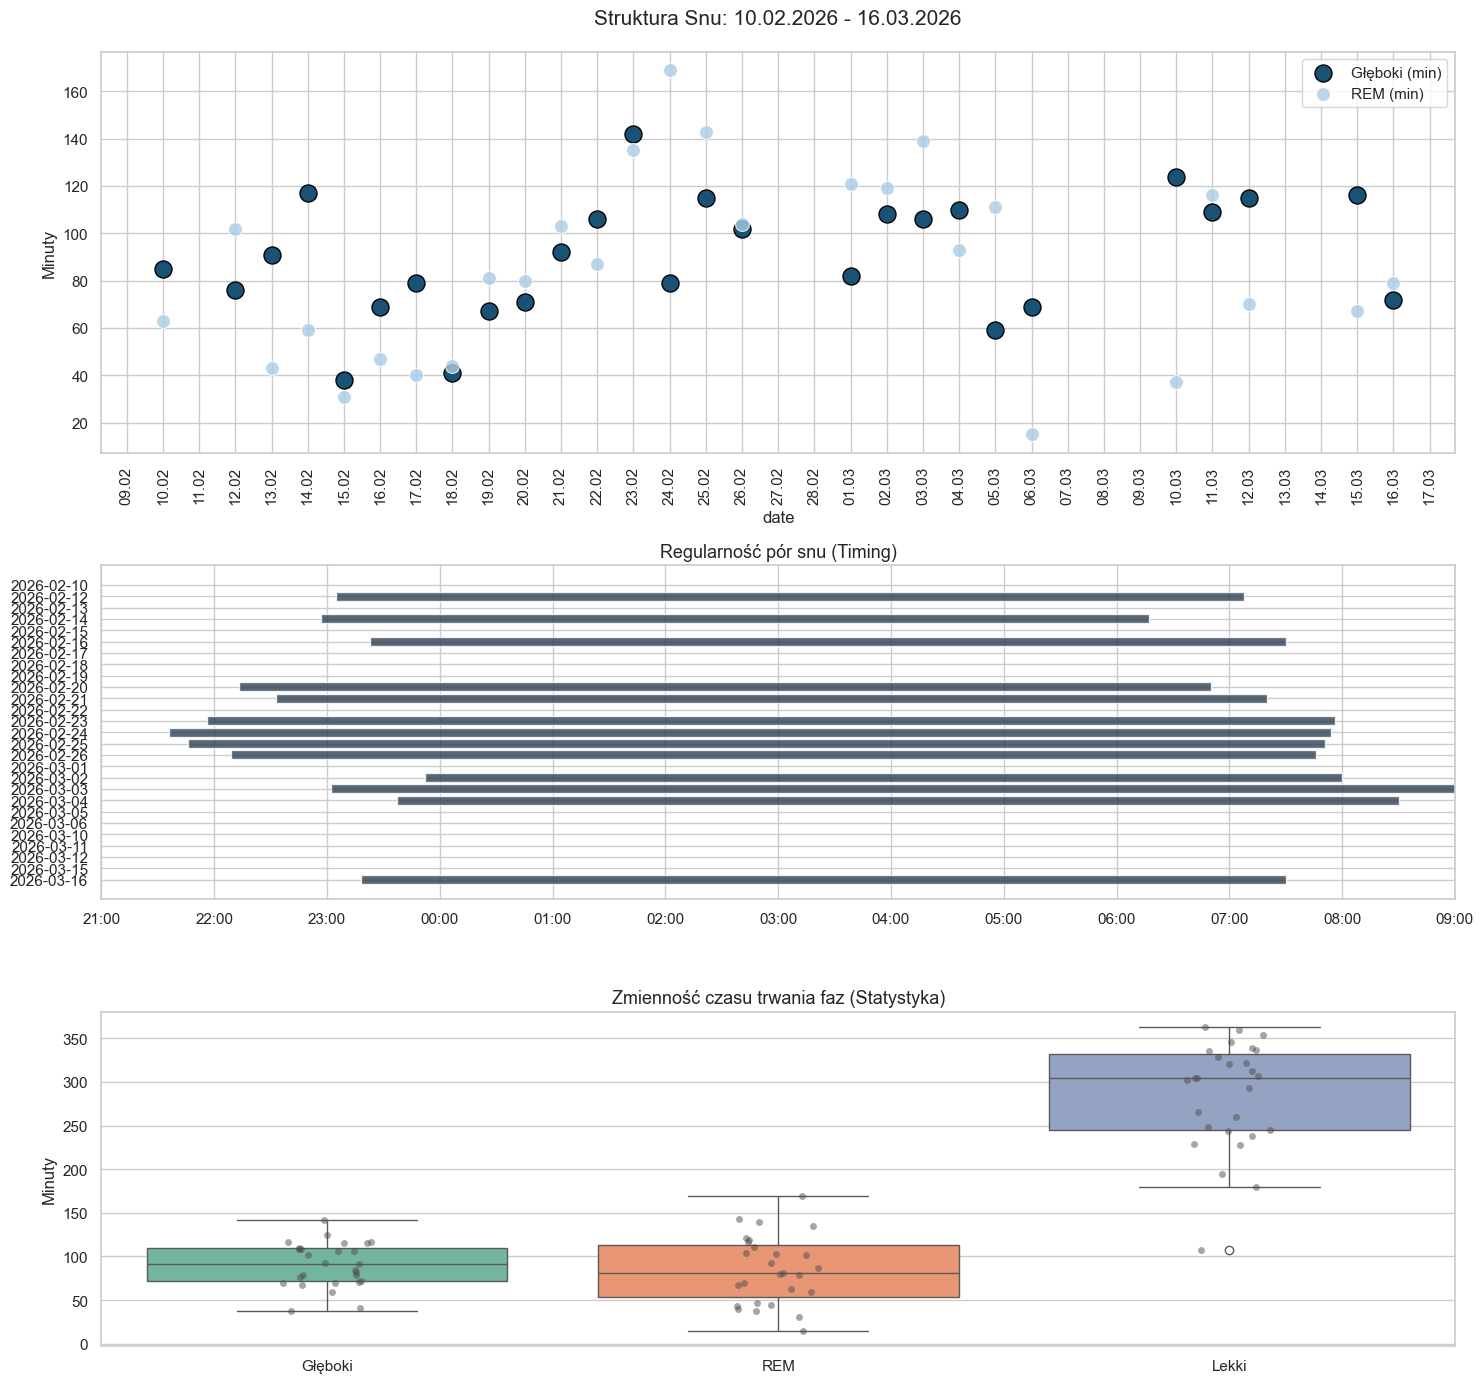

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

def plot_garmin_sleep_report(df):
    # --- 1. PRZYGOTOWANIE DANYCH ---
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    df['sleep_start'] = pd.to_datetime(df['sleep_start'])
    df['sleep_end'] = pd.to_datetime(df['sleep_end'])

    # Definiujemy zakres osi X zgodnie z Twoim życzeniem
    full_range = pd.date_range(start="2026-02-10", end="2026-03-16", freq='D')

    # Reindexacja dla zachowania przerw w danych na wykresie chronologicznym
    df_timeline = df.set_index('date').reindex(full_range).reset_index()
    df_timeline.rename(columns={'index': 'date'}, inplace=True)

    # --- 2. KONFIGURACJA ESTETYKI ---
    sns.set_theme(style="whitegrid")
    fig = plt.figure(figsize=(15, 14))
    gs = fig.add_gridspec(3, 1, height_ratios=[1.2, 1, 1])

    # --- WYKRES 1: CHRONOLOGIA FAZ (SCATTER) ---
    ax1 = fig.add_subplot(gs[0])
    sns.scatterplot(data=df_timeline, x='date', y='deep_sleep_min', s=150,
                    label='Głęboki (min)', ax=ax1, color='#1A5276', edgecolor='black')
    sns.scatterplot(data=df_timeline, x='date', y='rem_sleep_min', s=100,
                    label='REM (min)', ax=ax1, color='#A9CCE3', alpha=0.8)

    ax1.set_title("Struktura Snu: 10.02.2026 - 16.03.2026", fontsize=15, pad=20)
    ax1.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
    ax1.tick_params(axis='x', rotation=90)
    ax1.set_ylabel("Minuty")
    ax1.legend(loc='upper right')

    # --- WYKRES 2: OKNA CZASOWE (TIMING) ---
    ax2 = fig.add_subplot(gs[1])
    for i, row in df.iterrows():
        # Obliczamy godziny jako ułamek dziesiętny
        start_h = row['sleep_start'].hour + row['sleep_start'].minute/60
        end_h = row['sleep_end'].hour + row['sleep_end'].minute/60

        # Logika rysowania pasków (uwzględnia sen po północy)
        duration = (24 - start_h + end_h) if start_h > 12 else (end_h - start_h)
        ax2.barh(row['date'].strftime('%Y-%m-%d'), duration, left=start_h, color='#2E4053', alpha=0.8)

    ax2.set_xlim(21, 33) # Wyświetlamy od 21:00 do 09:00 rano
    ax2.set_xticks([21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33])
    ax2.set_xticklabels(['21:00', '22:00', '23:00', '00:00', '01:00', '02:00', '03:00', '04:00', '05:00', '06:00', '07:00', '08:00', '09:00'])
    ax2.set_title("Regularność pór snu (Timing)", fontsize=13)
    ax2.invert_yaxis() # Daty od góry do dołu

    # --- WYKRES 3: STABILNOŚĆ FAZ (BOXPLOT) ---
    ax3 = fig.add_subplot(gs[2])
    phases_map = {'deep_sleep_min': 'Głęboki', 'rem_sleep_min': 'REM', 'light_sleep_min': 'Lekki'}
    df_long = df.melt(id_vars=['date'], value_vars=list(phases_map.keys()), var_name='Faza', value_name='Minuty')
    df_long['Faza'] = df_long['Faza'].map(phases_map)

    # Poprawiony boxplot zgodnie z najnowszą wersją Seaborn
    sns.boxplot(data=df_long, x='Faza', y='Minuty', hue='Faza', palette='Set2', ax=ax3, legend=False)
    sns.stripplot(data=df_long, x='Faza', y='Minuty', color=".3", alpha=0.5, ax=ax3)

    ax3.set_title("Zmienność czasu trwania faz (Statystyka)", fontsize=13)
    ax3.set_xlabel("")

    plt.tight_layout()
    plt.show()

# Wywołanie:
plot_garmin_sleep_report(df_sleep)

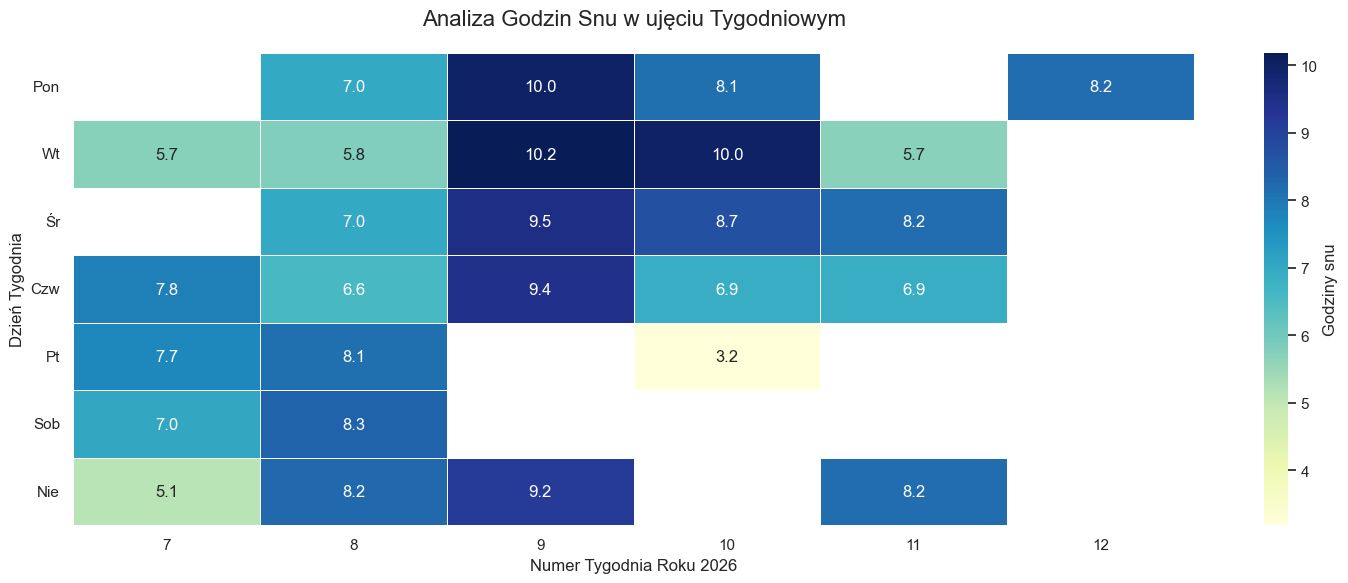

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_custom_sleep_heatmap(df):
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    df['duration_hours'] = df['duration_min'] / 60

    # 1. PRZYGOTOWANIE DANYCH DO MACIERZY
    # Musimy mieć: Dzień Tygodnia vs Numer Tygodnia
    df['week_number'] = df['date'].dt.isocalendar().week
    df['day_of_week'] = df['date'].dt.dayofweek # 0=Pon, 6=Nie
    df['month_name'] = df['date'].dt.month_name()

    # Mapowanie dni na polskie nazwy
    days_pl = ['Pon', 'Wt', 'Śr', 'Czw', 'Pt', 'Sob', 'Nie']

    # Tworzymy pivot table (macierz)
    # Jeśli masz dane z przełomu lat, dodaj też rok do indeksu
    pivot_df = df.pivot_table(index='day_of_week',
                              columns='week_number',
                              values='duration_hours')

    # Reindexujemy, aby na pewno mieć wszystkie dni tygodnia
    pivot_df = pivot_df.reindex(range(7))

    # 2. WIZUALIZACJA
    plt.figure(figsize=(15, 6))

    # Rysujemy heatmapę
    ax = sns.heatmap(pivot_df,
                     annot=True,      # Wpisz liczby godzin w kwadraty
                     fmt=".1f",       # Jedno miejsce po przecinku
                     cmap="YlGnBu",   # Kolory od żółtego do niebieskiego
                     cbar_kws={'label': 'Godziny snu'},
                     linewidths=.5,
                     linecolor='white')

    # Ustawienia osi
    ax.set_yticklabels(days_pl, rotation=0)
    ax.set_title('Analiza Godzin Snu w ujęciu Tygodniowym', fontsize=16, pad=20)
    ax.set_xlabel('Numer Tygodnia Roku 2026')
    ax.set_ylabel('Dzień Tygodnia')

    plt.tight_layout()
    plt.show()

# Wywołanie
plot_custom_sleep_heatmap(df_sleep)